In [1]:
%load_ext autoreload
%autoreload 2 

## Imports

In [2]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true"

In [3]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax
import pickle

In [4]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [5]:
import solve
import aux_ as aux
import RANK
import model_funcs
import neural_nets
import plotting

In [6]:
do_solve = True
do_save = True

## Device

In [7]:
device = aux.choose_gpu()

cuBLAS < 13.2 (120902 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


Avaliable devices:
cuda:0

Device = cuda:0 is choosen


## Training the neural network to the DSS and SSS

In [8]:
model = RANK.RANK_model(device)

E0528 05:05:10.676811 3816340 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 133.76GiB (143621603328 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0528 05:05:10.677302 3816340 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 120.38GiB (129259438080 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0528 05:05:10.677770 3816340 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 108.34GiB (116333494272 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0528 05:05:10.678226 3816340 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 97.51GiB (104700141568 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0528 05:05:10.678678 3816340 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 87.76GiB (9423012

In [9]:
sigma_eps_u = 0.001350
sigma_eps_z = 0.020814
sigma_eps_Gamma = 0.012778

sigma_quad = {
    "sigma_eps_u" : sigma_eps_u,
    "sigma_eps_z" :  sigma_eps_z,
    "sigma_eps_Gamma" : sigma_eps_Gamma
}

factor = 1
sigma_sim = {
    "sigma_eps_u" : factor*sigma_eps_u,
    "sigma_eps_z" :  factor*sigma_eps_z,
    "sigma_eps_Gamma" : factor*sigma_eps_Gamma
}

episode_list = [50_000, 2_500_000, 100_000]
lr_list = [1e-4, 1e-4, 5e-5]
N_list = [1000, 1000, 5000]
ZLB_list = [-1, -0.005, -0.005, 0.00]

In [10]:
if do_solve: solve.train_nn(model, episode_list, sigma_sim, sigma_quad, ZLB_list, lr_list, N_list, print_freq=100)

-------------------------------------------------- PHASE 0:  --------------------------------------------------
###### ZLB = -1, lr = 0.0001, N = 1000 ######

Episode 0:	Loss = 0.00514004	Best Loss = 0.00514004		SSS: Y = 0.974, pi = 0.000		ee = 0.06117700	nkpce = 0.03510600	(i<=0)-share = 0.000	ZLB-share = 0.000
Episode 100:	Loss = 0.00056075	Best Loss = 0.00056075		SSS: Y = 0.930, pi = -0.060		ee = 0.00919476	nkpce = 0.02130976	(i<=0)-share = 0.998	ZLB-share = 0.994
Episode 200:	Loss = 0.00018671	Best Loss = 0.00018671		SSS: Y = 0.903, pi = -0.054		ee = 0.00263913	nkpce = 0.01311111	(i<=0)-share = 1.000	ZLB-share = 1.000
Episode 300:	Loss = 0.00006459	Best Loss = 0.00006459		SSS: Y = 0.885, pi = -0.033		ee = 0.00187518	nkpce = 0.00764589	(i<=0)-share = 0.981	ZLB-share = 0.950
Episode 400:	Loss = 0.00001547	Best Loss = 0.00001547		SSS: Y = 0.871, pi = -0.016		ee = 0.00132426	nkpce = 0.00356556	(i<=0)-share = 0.715	ZLB-share = 0.559
Episode 500:	Loss = 0.00000360	Best Loss = 0.00000360	

KeyboardInterrupt: 

In [ ]:
if (do_solve and do_save): model.save('output/final_nn.pkl', model.nn)

In [ ]:
if not do_solve: model.load('output/final_nn.pkl', opt_load=False)

# Plots

In [ ]:
if (do_solve and do_save):
    for k,v in model.info.items():
        with open('output/info/'+ k+'.pkl', 'wb') as f:
            pickle.dump(v, f)

else:
    info = {}
    for k in ['train_losses', 'test_losses', 'ee_test_losses', 'nkpce_test_losses']:
        with open('output/info/' + k + '.pkl', 'rb') as f:
            info[k] = pickle.load(f)

            model.info = info

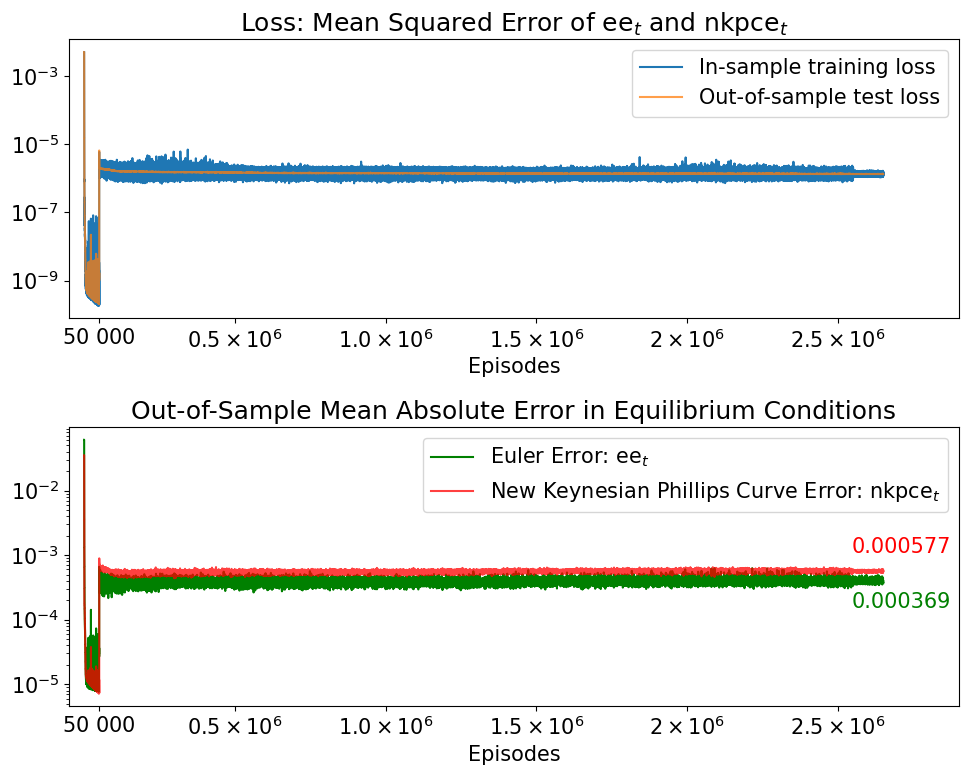

In [ ]:
plt.rcParams.update({'font.size': 15})

f, ax = plt.subplots(2,1,figsize=(10,8))

ax[0].plot(model.info['train_losses'], label=r'In-sample training loss')
ax[0].plot(model.info['test_losses'], alpha=0.75, label=r'Out-of-sample test loss')

ax[1].plot(model.info['ee_test_losses'], color='green', label=r'Euler Error: $\text{ee}_t$')
ax[1].plot(model.info['nkpce_test_losses'], alpha=0.75, color='red', label=r'New Keynesian Phillips Curve Error: $\text{nkpce}_t$')

xticks = [
    50_000,
    0.5*10**6,
    10**6,
    1.5*10**6,
    2*10**6,
    2.5*10**6
]

xlabels = [
    r'$50 \ 000$',
    r'$0.5\times10^6$',
    r'$1.0\times10^6$',
    r'$1.5\times10^6$',
    r'$2\times10^6$',
    r'$2.5\times10^6$'
]

for i in range(2):
    ax[i].set_xlim([-50000, 2.9*1e6])
    ax[i].set_yscale('log')
    ax[i].set_xticks(xticks)
    ax[i].set_xticklabels(xlabels)
    ax[i].set_xlabel('Episodes')
    ax[i].legend()

ax[0].set_title(r'Loss: Mean Squared Error of $\text{ee}_t$ and $\text{nkpce}_t$')
ax[1].set_title(r'Out-of-Sample Mean Absolute Error in Equilibrium Conditions')

ax[1].text(0.88, 0.55, f'{model.info["nkpce_test_losses"][-1]:.6f}', 
           transform=ax[1].transAxes, color='red', fontsize=15)

ax[1].text(0.88, 0.35, f'{model.info["ee_test_losses"][-1]:.6f}', 
           transform=ax[1].transAxes, color='green', fontsize=15)

f.tight_layout()

if do_save: f.savefig('plots/training_nns.png', bbox_inches='tight')